Time Series Final Project: EDA

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import glob
import os

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.seasonal import seasonal_decompose

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# load monthly ride data
path = '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/monthly_counts/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# Create a list of DataFrames by reading each CSV file
df_list = [pd.read_csv(filename) for filename in all_files]

# Concatenate all DataFrames in the list into a single DataFrame
monthly_rides = pd.concat(df_list, ignore_index=True).drop(columns=["Unnamed: 0"])

# Display the combined DataFrame
monthly_rides.head()

,month,num_trips
0,2024-01-01T00:00:00.000,425203
1,2024-02-01T00:00:00.000,440013
2,2024-03-01T00:00:00.000,524134
3,2024-04-01T00:00:00.000,546369
4,2024-05-01T00:00:00.000,619945


In [4]:
# basic EDA

monthly_rides = monthly_rides.copy()
monthly_rides["month"] = pd.to_datetime(monthly_rides["month"])
monthly_rides = monthly_rides.sort_values("month")
monthly_rides.set_index("month", inplace=True)

monthly_rides.info()
monthly_rides.describe()


<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 157 entries, 2013-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   num_trips  157 non-null    int64
dtypes: int64(1)
memory usage: 2.5 KB


,num_trips
count,1.570000e+02
mean,1.432975e+06
std,1.015816e+06
min,2.700000e+01
25%,5.427880e+05
50%,1.335504e+06
75%,2.362105e+06
max,3.510897e+06


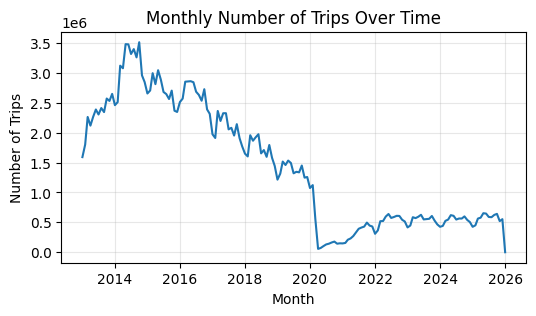

In [18]:
plt.figure(figsize=(6, 3))
plt.plot(monthly_rides.index, monthly_rides["num_trips"])
plt.title("Monthly Number of Trips Over Time")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.grid(alpha=0.3)
plt.show()


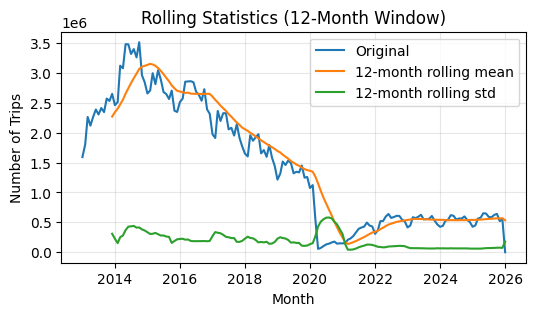

In [19]:
window = 12  # 12-month rolling window

plt.figure(figsize=(6, 3))
plt.plot(monthly_rides["num_trips"], label="Original")
plt.plot(
    monthly_rides["num_trips"].rolling(window).mean(),
    label="12-month rolling mean"
)
plt.plot(
    monthly_rides["num_trips"].rolling(window).std(),
    label="12-month rolling std"
)
plt.title("Rolling Statistics (12-Month Window)")
plt.xlabel("Month")
plt.ylabel("Number of Trips")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


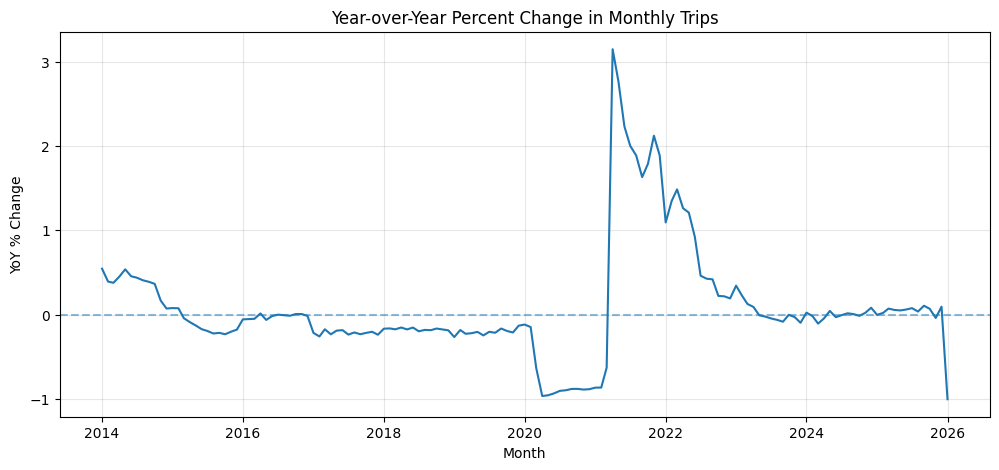

In [7]:
monthly_rides["yoy_change"] = (
    monthly_rides["num_trips"]
    .pct_change(periods=12)
)

plt.figure(figsize=(12, 5))
plt.plot(monthly_rides.index, monthly_rides["yoy_change"])
plt.axhline(0, linestyle="--", alpha=0.5)
plt.title("Year-over-Year Percent Change in Monthly Trips")
plt.xlabel("Month")
plt.ylabel("YoY % Change")
plt.grid(alpha=0.3)
plt.show()


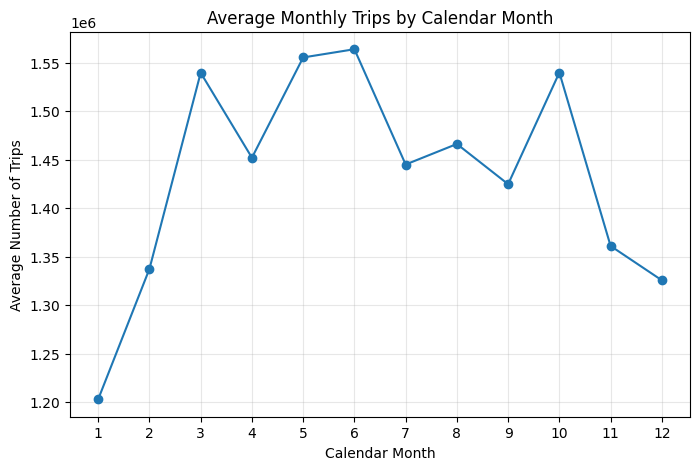

In [8]:
monthly_rides["calendar_month"] = monthly_rides.index.month

monthly_avg = (
    monthly_rides
    .groupby("calendar_month")["num_trips"]
    .mean()
)

plt.figure(figsize=(8, 5))
plt.plot(monthly_avg.index, monthly_avg.values, marker="o")
plt.xticks(range(1, 13))
plt.xlabel("Calendar Month")
plt.ylabel("Average Number of Trips")
plt.title("Average Monthly Trips by Calendar Month")
plt.grid(alpha=0.3)
plt.show()


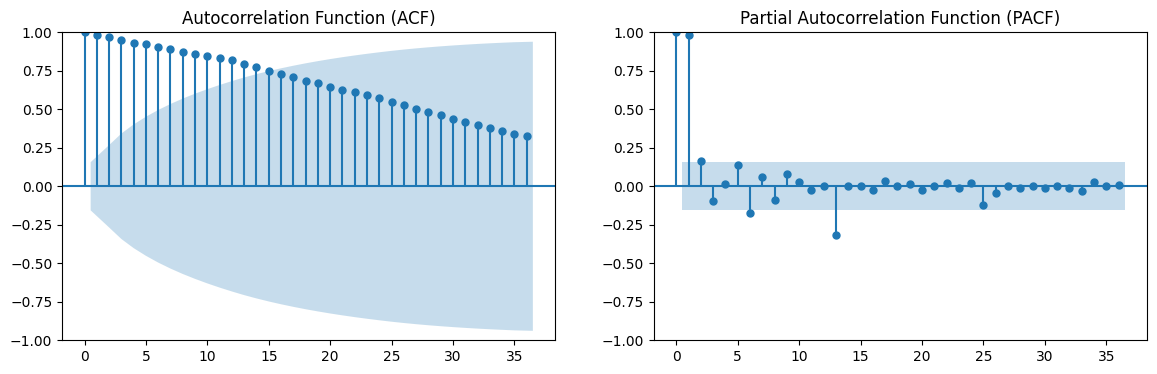

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(monthly_rides["num_trips"], lags=36, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(monthly_rides["num_trips"], lags=36, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.show()



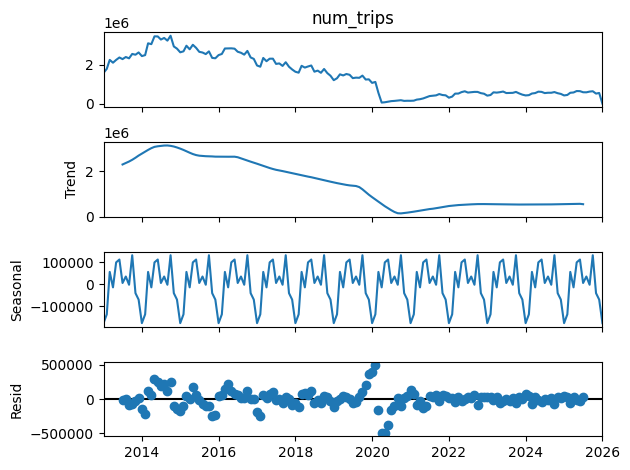

In [22]:
decomp = seasonal_decompose(
    monthly_rides["num_trips"],
    model="additive",
    period=12,
)

decomp.plot()
plt.show()


In [11]:
# load daily ride data
path = path = '/content/drive/Shareddrives/Time Series Group 5/Final_Project/data/daily_counts/'
all_files = glob.glob(os.path.join(path, "*.csv"))

# Create a list of DataFrames by reading each CSV file
df_list = [pd.read_csv(filename) for filename in all_files]

# Concatenate all DataFrames in the list into a single DataFrame
daily_rides = pd.concat(df_list, ignore_index=True).drop(columns=["Unnamed: 0"])

# Display the combined DataFrame
daily_rides.head()

,day,num_trips
0,2024-01-01T00:00:00.000,9511
1,2024-01-02T00:00:00.000,12807
2,2024-01-03T00:00:00.000,13449
3,2024-01-04T00:00:00.000,13825
4,2024-01-05T00:00:00.000,12953


In [12]:
# basic eda:

daily_rides = daily_rides.copy()
daily_rides["day"] = pd.to_datetime(daily_rides["day"], errors="raise", format='mixed')
daily_rides = daily_rides.sort_values("day")
daily_rides.set_index("day", inplace=True)

daily_rides.info()
daily_rides.describe()



<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 4749 entries, 2013-01-01 to 2026-01-01
Data columns (total 1 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   num_trips  4749 non-null   int64
dtypes: int64(1)
memory usage: 74.2 KB


,num_trips
count,4749.000000
mean,47373.572963
std,34599.980944
min,27.000000
25%,16644.000000
50%,41861.000000
75%,76848.000000
max,170271.000000


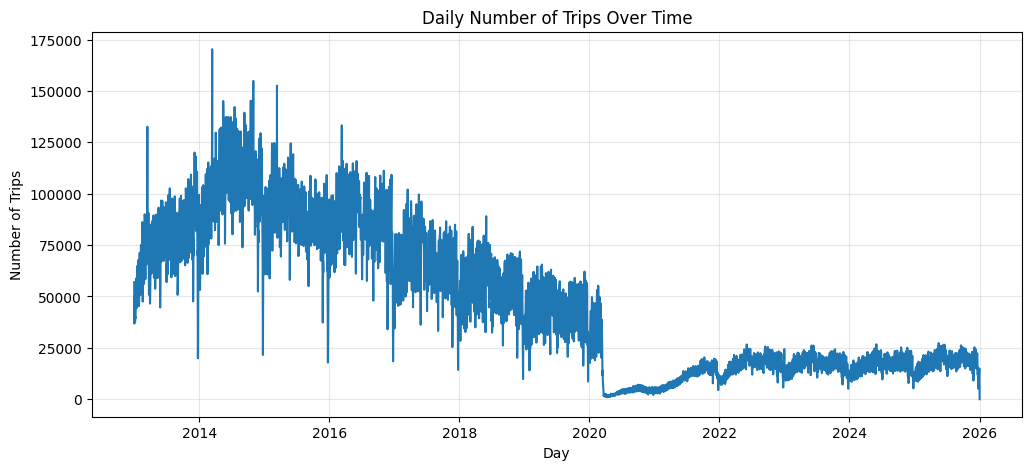

In [13]:
plt.figure(figsize=(12, 5))
plt.plot(daily_rides.index, daily_rides["num_trips"])
plt.title("Daily Number of Trips Over Time")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.grid(alpha=0.3)
plt.show()

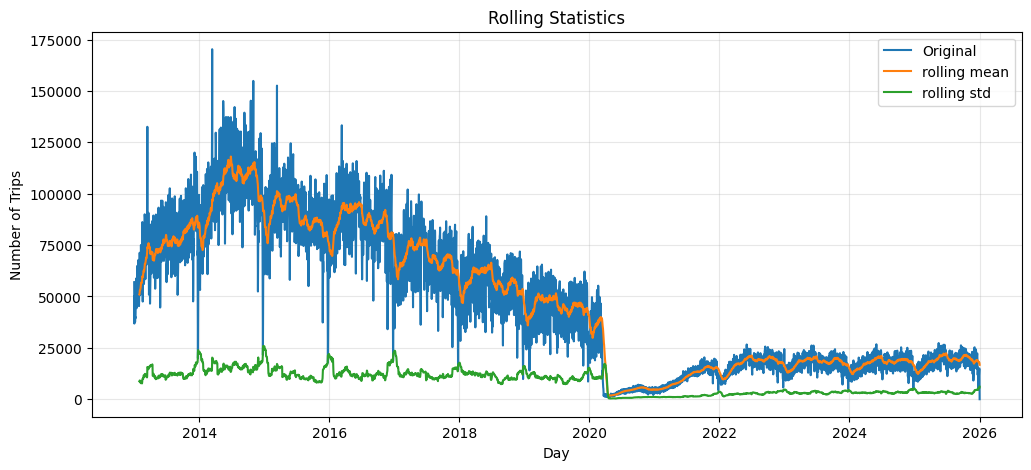

In [14]:
window = 30  #30-day rolling window

plt.figure(figsize=(12, 5))
plt.plot(daily_rides["num_trips"], label="Original")
plt.plot(
    daily_rides["num_trips"].rolling(window).mean(),
    label="rolling mean"
)
plt.plot(
    daily_rides["num_trips"].rolling(window).std(),
    label="rolling std"
)
plt.title("Rolling Statistics")
plt.xlabel("Day")
plt.ylabel("Number of Trips")
plt.legend()
plt.grid(alpha=0.3)
plt.show()


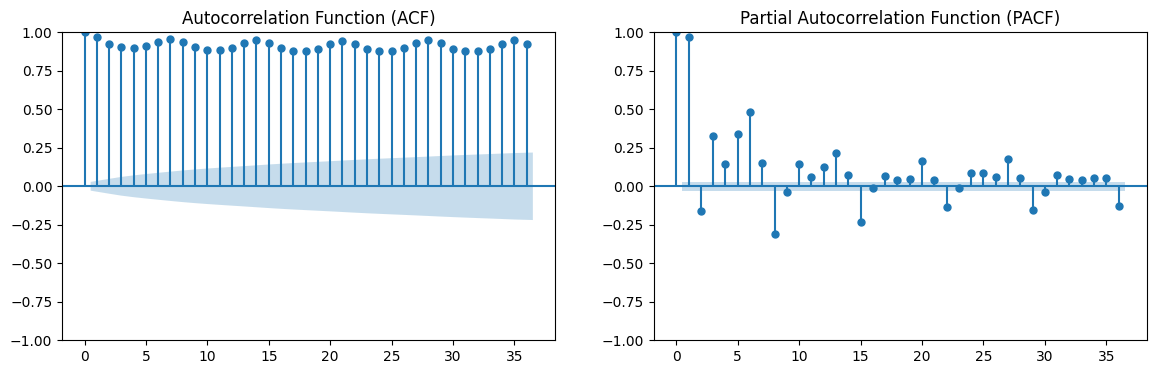

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

plot_acf(daily_rides["num_trips"], lags=36, ax=axes[0])
axes[0].set_title("Autocorrelation Function (ACF)")

plot_pacf(daily_rides["num_trips"], lags=36, ax=axes[1])
axes[1].set_title("Partial Autocorrelation Function (PACF)")

plt.show()
